In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk Modeling & Evaluasi
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Konfigurasi Visualisasi
sns.set_style("whitegrid")

In [2]:
# ==============================================================================
# REVISI BAGIAN 2: LOAD DATASET BARU
# ==============================================================================
print("--- [1] LOADING & CLEANING DATA ---")
filename = 'Spotify Tracks Dataset.csv'  # <--- File Baru

try:
    df = pd.read_csv(filename)

    # 1. Hapus kolom index yang tidak perlu (Unnamed: 0)
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    # 2. Handling Missing Values
    df_clean = df.dropna().copy()

    # 3. Handling Duplicates (Penting! Dataset besar sering ada duplikat)
    df_clean = df_clean.drop_duplicates(subset=['track_id'])

    # 4. Konversi tipe data (Explicit: Boolean -> Int)
    # Di dataset ini explicit mungkin sudah boolean atau string, kita pastikan jadi 0/1
    df_clean['explicit'] = df_clean['explicit'].astype(int)

    # 5. Filter Genre (Studi Kasus: Ambil 3 Genre untuk perbandingan tajam)
    # Pastikan nama kolom targetnya 'track_genre'
    target_genres = ['acoustic', 'rock', 'world-music'] # Bisa ganti genre lain jika mau
    df_final = df_clean[df_clean['track_genre'].isin(target_genres)].copy()

    print(f"Dataset Loaded. Dimensi Data: {df_final.shape}")
    print(f"Kolom tersedia: {df_final.columns.tolist()}")

except FileNotFoundError:
    print("❌ Error: File csv tidak ditemukan.")

--- [1] LOADING & CLEANING DATA ---
Dataset Loaded. Dimensi Data: (2265, 20)
Kolom tersedia: ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']



--- [2] EXPLORATORY DATA ANALYSIS (EDA) ---


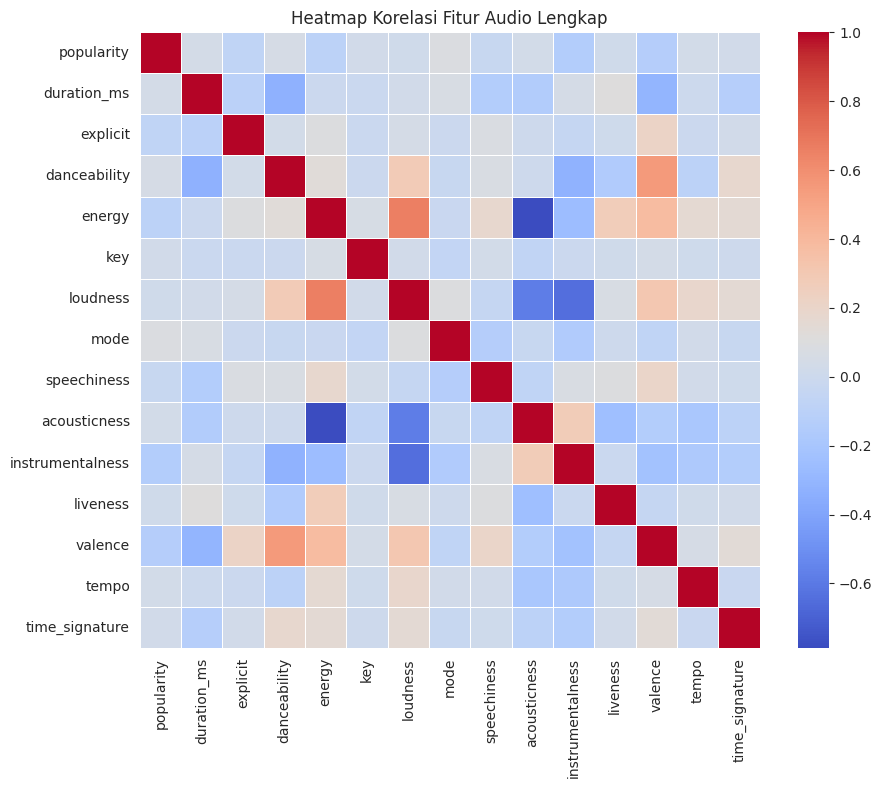

/tmp/ipython-input-508585736.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='track_genre', y='popularity', data=df_final, palette='Set2')


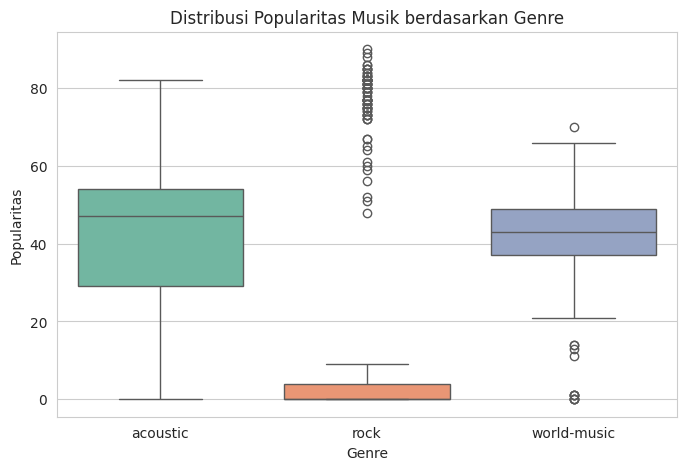

/tmp/ipython-input-508585736.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='track_genre', y='energy', data=df_final, palette='viridis', errorbar=None)


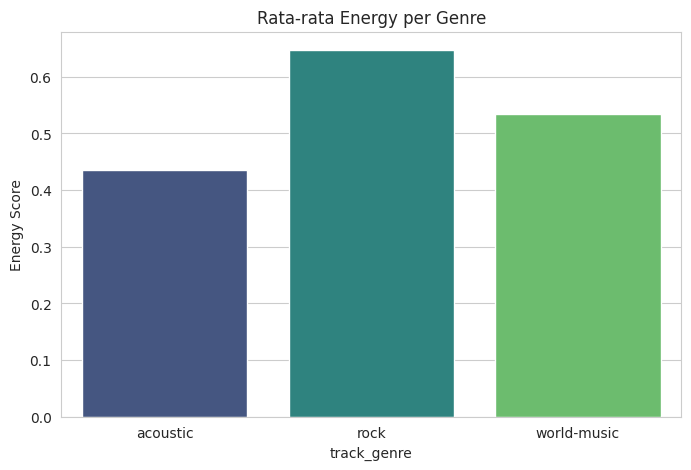

In [3]:
# ==============================================================================
# REVISI BAGIAN 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
print("\n--- [2] EXPLORATORY DATA ANALYSIS (EDA) ---")

# Visualisasi A: Korelasi Antar Fitur Audio (Heatmap)
# Heatmap ini otomatis menyesuaikan dengan kolom angka yang ada (termasuk danceability, energy, dll)
plt.figure(figsize=(10, 8)) # Ukuran diperbesar sedikit agar muat banyak fitur
numeric_df = df_final.select_dtypes(include=[np.number]) # Hanya ambil kolom angka
corr = numeric_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5) # annot=False agar tidak penuh angka
plt.title('Heatmap Korelasi Fitur Audio Lengkap')
plt.show()

# Visualisasi B: Distribusi Popularitas per Genre (Boxplot)
plt.figure(figsize=(8, 5))
# PERBAIKAN DISINI: Ganti 'genre' menjadi 'track_genre'
sns.boxplot(x='track_genre', y='popularity', data=df_final, palette='Set2')
plt.title('Distribusi Popularitas Musik berdasarkan Genre')
plt.xlabel('Genre')
plt.ylabel('Popularitas')
plt.show()

# Visualisasi C (Tambahan): Perbandingan Karakteristik Audio
# Melihat perbedaan 'Energy' antar genre (Bukti fitur ini penting)
plt.figure(figsize=(8, 5))
sns.barplot(x='track_genre', y='energy', data=df_final, palette='viridis', errorbar=None)
plt.title('Rata-rata Energy per Genre')
plt.ylabel('Energy Score')
plt.show()

In [4]:
# ==============================================================================
# BAGIAN 4: SELEKSI FITUR (Feature Selection)
# ==============================================================================
print("\n--- [3] SELEKSI FITUR & ANALISIS PENTINGNYA FITUR ---")

# 1. Definisikan Fitur Audio Lengkap (Bahan Baku)
# Fitur-fitur inilah yang membedakan karakteristik suara antar genre
audio_features = [
    'popularity', 'duration_ms', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

available_features = [col for col in audio_features if col in df_final.columns]
print(f"Fitur yang digunakan ({len(available_features)} fitur): {available_features}")

# 2. Analisis Statistik (ANOVA) untuk melihat fitur mana yang paling 'Penting'
X_temp = df_final[available_features]
y_temp = df_final['track_genre']

selector = SelectKBest(score_func=f_classif, k='all')
fit = selector.fit(X_temp, y_temp)

# Tampilkan Ranking Fitur
feature_scores = pd.DataFrame({'Fitur': X_temp.columns, 'Score': fit.scores_})
print("\nRanking Kepentingan Fitur (Top 10):")
print(feature_scores.sort_values(by='Score', ascending=False).head(10))


--- [3] SELEKSI FITUR & ANALISIS PENTINGNYA FITUR ---
Fitur yang digunakan (14 fitur): ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

Ranking Kepentingan Fitur (Top 10):
               Fitur       Score
3       danceability  285.167800
0         popularity  250.973253
12           valence  234.134826
9       acousticness  224.561957
1        duration_ms  153.891954
4             energy  115.324789
11          liveness   82.258357
6           loudness   49.934698
7               mode   27.737386
10  instrumentalness   25.543662


In [5]:
# ==============================================================================
# BAGIAN 5: PREPARATION & DATA SPLITTING
# ==============================================================================
print("\n--- [4] PREPARATION & SPLITTING ---")

# 1. Definisi Variabel X dan y Akhir
X = df_final[available_features]
y = df_final['track_genre']

# 2. Encoding Target (String -> Angka)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Target Genre diubah menjadi angka: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 3. Split Data (Train 80%, Test 20%)
# Menggunakan stratify=y agar perbandingan genre di data Latih dan Uji seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Data siap! Ukuran Train: {X_train.shape}, Ukuran Test: {X_test.shape}")


--- [4] PREPARATION & SPLITTING ---
Target Genre diubah menjadi angka: {'acoustic': np.int64(0), 'rock': np.int64(1), 'world-music': np.int64(2)}
Data siap! Ukuran Train: (1812, 14), Ukuran Test: (453, 14)


In [9]:
# ==============================================================================
# BAGIAN 6: MODELING (Pipeline, Tuning, & Saving)
# ==============================================================================
print("\n--- [5] MODELING DENGAN PIPELINE & HYPERPARAMETER TUNING ---")

# 1. Membuat Pipeline (Scaler + Random Forest)
# StandardScaler penting untuk menormalkan fitur seperti 'loudness' (negatif) dan 'tempo' (ratusan)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 2. Setup Parameter Grid (Diperluas untuk Dataset Besar)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__min_samples_split': [2, 5]
}

# 3. Setup Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("⏳ Sedang melatih model... (Proses ini mungkin memakan waktu 2-5 menit)")
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 4. Ambil Model Terbaik
best_model = grid_search.best_estimator_
print(f"✅ Parameter Terbaik: {grid_search.best_params_}")

# 5. SIMPAN MODEL
import joblib
model_filename = 'UAS_BDDM_5449.joblib'
joblib.dump(best_model, model_filename)
print(f"💾 Model berhasil disimpan sebagai: {UAS_BDDM_5449}")


--- [5] MODELING DENGAN PIPELINE & HYPERPARAMETER TUNING ---
⏳ Sedang melatih model... (Proses ini mungkin memakan waktu 2-5 menit)
✅ Parameter Terbaik: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


NameError: name 'UAS_BDDM_5449' is not defined


--- [6] EVALUASI PERFORMA MODEL ---

Laporan Klasifikasi (Test Set):
              precision    recall  f1-score   support

    acoustic       0.87      0.86      0.87       200
        rock       0.90      0.94      0.92        68
 world-music       0.88      0.88      0.88       185

    accuracy                           0.88       453
   macro avg       0.89      0.89      0.89       453
weighted avg       0.88      0.88      0.88       453



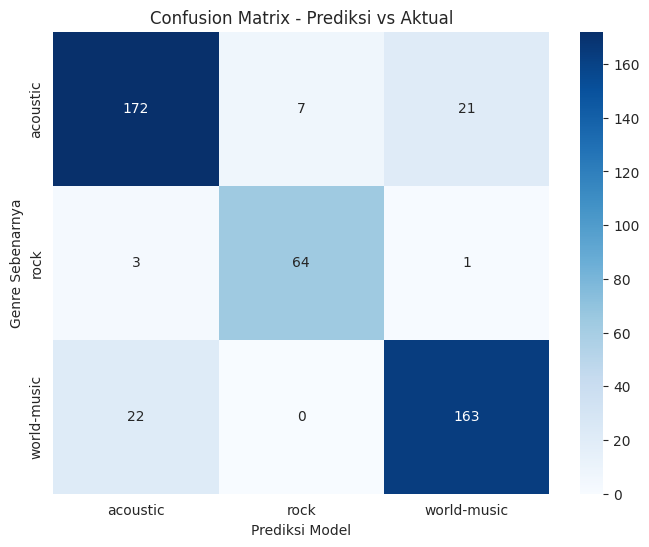

⏳ Menghitung skor stabilitas (Cross Validation)...

=== KESIMPULAN AKHIR ===
Rata-rata Akurasi (Validasi): 86.37% (+/- 1.11%)
Rata-rata F1-Score: 86.35%


In [10]:
# ==============================================================================
# BAGIAN 7: EVALUASI PERFORMA MODEL
# ==============================================================================
print("\n--- [6] EVALUASI PERFORMA MODEL ---")

# 1. Prediksi Data Test
y_pred = best_model.predict(X_test)

# 2. Classification Report (Detail Akurasi per Genre)
print("\nLaporan Klasifikasi (Test Set):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 3. Confusion Matrix (Visualisasi Salah/Benar)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Prediksi vs Aktual')
plt.xlabel('Prediksi Model')
plt.ylabel('Genre Sebenarnya')
plt.show()

# 4. Validasi Stabilitas (Cross Validation Score)
print("⏳ Menghitung skor stabilitas (Cross Validation)...")
cv_results = cross_validate(best_model, X_train, y_train, cv=cv, scoring=['accuracy', 'f1_weighted'])

print("\n=== KESIMPULAN AKHIR ===")
print(f"Rata-rata Akurasi (Validasi): {cv_results['test_accuracy'].mean()*100:.2f}% (+/- {cv_results['test_accuracy'].std()*100:.2f}%)")
print(f"Rata-rata F1-Score: {cv_results['test_f1_weighted'].mean()*100:.2f}%")